** Final CODE AMBIGUOUS VERBS IN  TOURISM DATASET**

In [ ]:
# Connect Google Drive and fetch folder files
from google.colab import drive
import os
import re
from collections import defaultdict

drive.mount('/content/drive')

# Set the folders in Google Drive
text_folder = '/content/drive/MyDrive/MAR-TOURISM'
index_folder = '/content/drive/MyDrive'

# Step 1: Load indexverb_txt file for verb senses
index_file = os.path.join(index_folder, "idxverb_txt")
lemma_senses = defaultdict(lambda: {'count': 0, 'senses': []})

with open(index_file, 'r', encoding='utf-8') as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) >= 4:
            lemma = parts[0].strip()
            try:
                # Sense count is at index 4
                count = int(parts[4].strip())
                senses = parts[5:5+count]
                lemma_senses[lemma]['count'] = count
                lemma_senses[lemma]['senses'] = senses
            except ValueError:
                continue

# Step 2: Extract all verbs using only the first lemma from MAR-HEALTH files
verb_occurrences = defaultdict(set)

for filename in os.listdir(text_folder):
    if filename.endswith(".txt"):
        filepath = os.path.join(text_folder, filename)
        with open(filepath, 'r', encoding='utf-8') as f:
            for line in f:
                # Match pattern: जन्म#{जन्मणे,जन्म}#v#w6#3436
                matches = re.findall(r'(\S+)#\{([^}]+)\}#v#w\d+#(\d+)', line)
                for surface, group, sense_id in matches:
                    first_lemma = group.split(',')[0].strip()
                    if first_lemma:
                        verb_occurrences[first_lemma].add(sense_id)

# Step 3: Print full details for all detected verbs
print("\n--- All Verbs Used in MAR-TOURISM Corpus ---")
verb_2plus_count = 0
verbs_with_2plus_senses = []

for lemma, used_ids in sorted(verb_occurrences.items()):
    sense_info = lemma_senses.get(lemma, {'count': 0, 'senses': []})
    sense_count = sense_info['count']
    print(f"{lemma} | No. of Senses: {sense_count} | Used Sense IDs: {sorted(used_ids)}")
    if sense_count >= 2:
        verb_2plus_count += 1
        verbs_with_2plus_senses.append((lemma, sense_count, sorted(used_ids)))

print("\nTotal unique verbs with 2 or more senses:", verb_2plus_count)
print("\nTotal unique verbs :",len(verb_occurrences))
print("\nList of verbs with 2 or more senses (with count and used sense IDs):")
for verb, count, sense_ids in verbs_with_2plus_senses:
    print(f"{verb} | No. of Senses: {count} | Used Sense IDs: {sense_ids}")



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

--- All Verbs Used in MAR-TOURISM Corpus ---
अनुभवणे | No. of Senses: 2 | Used Sense IDs: ['17567']
अभ्यासणे | No. of Senses: 2 | Used Sense IDs: ['11727']
असणे | No. of Senses: 9 | Used Sense IDs: ['10794', '10876', '28203']
आकर्षणे | No. of Senses: 1 | Used Sense IDs: ['4693']
आकारणे | No. of Senses: 1 | Used Sense IDs: ['54276']
आणणे | No. of Senses: 4 | Used Sense IDs: ['10824']
आरंभणे | No. of Senses: 2 | Used Sense IDs: ['4704']
आले | No. of Senses: 0 | Used Sense IDs: ['12189', '6094']
आलेला | No. of Senses: 0 | Used Sense IDs: ['6094']
आवडणे | No. of Senses: 2 | Used Sense IDs: ['10987', '2468']
उघड | No. of Senses: 0 | Used Sense IDs: ['12233']
उघडणे | No. of Senses: 10 | Used Sense IDs: ['12234', '12241']
उभारणे | No. of Senses: 2 | Used Sense IDs: ['12197', '53274']
उरणे | No. of Senses: 1 | Used Sense IDs: ['6436']
ऊन | No. of Senses: 0 | Used Se

In [ ]:
!pip install transformers datasets scikit-learn torch pandas

PROPOSED ALGORITHM IMPLEMENTATION

In [ ]:
!pip install transformers datasets scikit-learn torch pandas numpy

import os
import glob
import pandas as pd
import numpy as np
import torch
import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
import warnings
warnings.filterwarnings('ignore')

# ---------------------------------------------------------
# 1. LOAD YOUR MASTER VERB LIST (The CSV)
# ---------------------------------------------------------
print("Loading your master list of polysemous verbs...")
df_my_verbs = pd.read_csv('/content/drive/MyDrive/polysemous_marathi_verbs.csv')
my_polysemous_list = df_my_verbs['Verb_Lemma'].tolist()
print(f"Loaded {len(my_polysemous_list)} specific verbs from your CSV.")

# ---------------------------------------------------------
# 2. PARSE THE FOLDER & FILTER USING YOUR CSV
# ---------------------------------------------------------
def parse_folder_and_filter(folder_path, valid_verbs_list):
    extracted_data = []
    txt_files = glob.glob(os.path.join(folder_path, '*.txt'))
    print(f"Found {len(txt_files)} text files in the directory. Extracting sentences...")

    if len(txt_files) == 0:
        raise ValueError("No .txt files found! Check if the files in MAR-TOURISM end with .txt")

    for file_path in txt_files:
        with open(file_path, 'r', encoding='utf-8') as file:
            for line in file:
                line = line.strip()
                if not line or line.startswith('ctx_'): continue

                clean_sentence = re.sub(r'#.*?(?=\s|$)', '', line)
                tokens = line.split()

                for token in tokens:
                    parts = token.split('#')
                    if len(parts) >= 5 and parts[2].lower() == 'v':
                        raw_lemma = parts[1].strip()
                        sense_id = parts[4].strip()

                        if ',' in raw_lemma:
                            lemma = raw_lemma.split(',')[1].strip(' }')
                        else:
                            lemma = raw_lemma.strip(' {}')

                        if lemma in valid_verbs_list and sense_id.isdigit() and sense_id != '0':
                            extracted_data.append({
                                'clean_sentence': clean_sentence.strip(),
                                'verb': lemma,
                                'sense_id': sense_id
                            })

    return pd.DataFrame(extracted_data)

folder_path = '/content/drive/MyDrive/MAR-TOURISM'
df_poly = parse_folder_and_filter(folder_path, my_polysemous_list)
print(f"Successfully extracted {len(df_poly)} sentences.")

label_encoder = LabelEncoder()
df_poly['label'] = label_encoder.fit_transform(df_poly['sense_id'])
num_labels = len(label_encoder.classes_)

# ---------------------------------------------------------
# 3. FILTER SINGLETONS & DATA SPLITTING (THE FIX)
# ---------------------------------------------------------
label_counts = df_poly['label'].value_counts()
valid_labels = label_counts[label_counts >= 2].index
df_poly = df_poly[df_poly['label'].isin(valid_labels)]

print(f"Removed singletons. Final sentences for training: {len(df_poly)}")

train_texts, test_texts, train_labels, test_labels = train_test_split(
    df_poly['clean_sentence'].tolist(), df_poly['label'].tolist(),
    test_size=0.20, random_state=42, stratify=df_poly['label']
)

# =========================================================
# EXPERIMENT A: COMPARATIVE BASELINE (TF-IDF + SVM)
# =========================================================
print("\n--- Starting Experiment A: TF-IDF + SVM Baseline ---")
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_svm = vectorizer.fit_transform(train_texts)
X_test_svm = vectorizer.transform(test_texts)

svm_model = SVC(kernel='linear', C=1.0, random_state=42)
svm_model.fit(X_train_svm, train_labels)

svm_predictions = svm_model.predict(X_test_svm)
svm_acc = accuracy_score(test_labels, svm_predictions)
svm_f1 = f1_score(test_labels, svm_predictions, average='macro')
print(f"RESULTS -> SVM Accuracy: {svm_acc:.4f} | SVM Macro F1: {svm_f1:.4f}")

# =========================================================
# EXPERIMENT B: PROPOSED ALGORITHM (MahaBERT)
# =========================================================
print("\n--- Starting Experiment B: MahaBERT Contextual Framework ---")
model_name = "l3cube-pune/marathi-bert-v2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels, ignore_mismatched_sizes=True)

def tokenize_function(texts):
    return tokenizer(texts, padding="max_length", truncation=True, max_length=128)

train_encodings = tokenize_function(train_texts)
test_encodings = tokenize_function(test_texts)

class MarathiWSDDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = MarathiWSDDataset(train_encodings, train_labels)
test_dataset = MarathiWSDDataset(test_encodings, test_labels)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average='macro')
    return {"accuracy": acc, "macro_f1": f1}

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=4,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    eval_strategy="epoch",
    logging_steps=50,
    learning_rate=2e-5,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

print("Training MahaBERT on polysemous verbs. This may take a few minutes...")
trainer.train()

print("\nEvaluating MahaBERT on Test Set...")
bert_results = trainer.evaluate(test_dataset)
bert_acc = bert_results['eval_accuracy']
bert_f1 = bert_results['eval_macro_f1']

print("\n=========================================================")
print("FINAL COMPARATIVE RESULTS FOR MANUSCRIPT")
print("=========================================================")
print(f"Baseline (TF-IDF + SVM) : Accuracy = {svm_acc:.4f}, Macro-F1 = {svm_f1:.4f}")
print(f"Proposed (MahaBERT)     : Accuracy = {bert_acc:.4f}, Macro-F1 = {bert_f1:.4f}")
print("=========================================================")

Loading your master list of polysemous verbs...
Loaded 87 specific verbs from your CSV.
Found 152 text files in the directory. Extracting sentences...
Successfully extracted 3598 sentences.
Removed singletons. Final sentences for training: 3548

--- Starting Experiment A: TF-IDF + SVM Baseline ---
RESULTS -> SVM Accuracy: 0.6549 | SVM Macro F1: 0.0560

--- Starting Experiment B: MahaBERT Contextual Framework ---


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: l3cube-pune/marathi-bert-v2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider tr

Training MahaBERT on polysemous verbs. This may take a few minutes...


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,4.578004,4.317148,0.547887,0.008428
2,3.648944,3.454954,0.547887,0.008428
3,3.147639,2.900708,0.547887,0.008428
4,2.775243,2.743640,0.547887,0.008428


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Evaluating MahaBERT on Test Set...



FINAL COMPARATIVE RESULTS FOR MANUSCRIPT
Baseline (TF-IDF + SVM) : Accuracy = 0.6549, Macro-F1 = 0.0560
Proposed (MahaBERT)     : Accuracy = 0.5479, Macro-F1 = 0.0084


VISUALIZATION

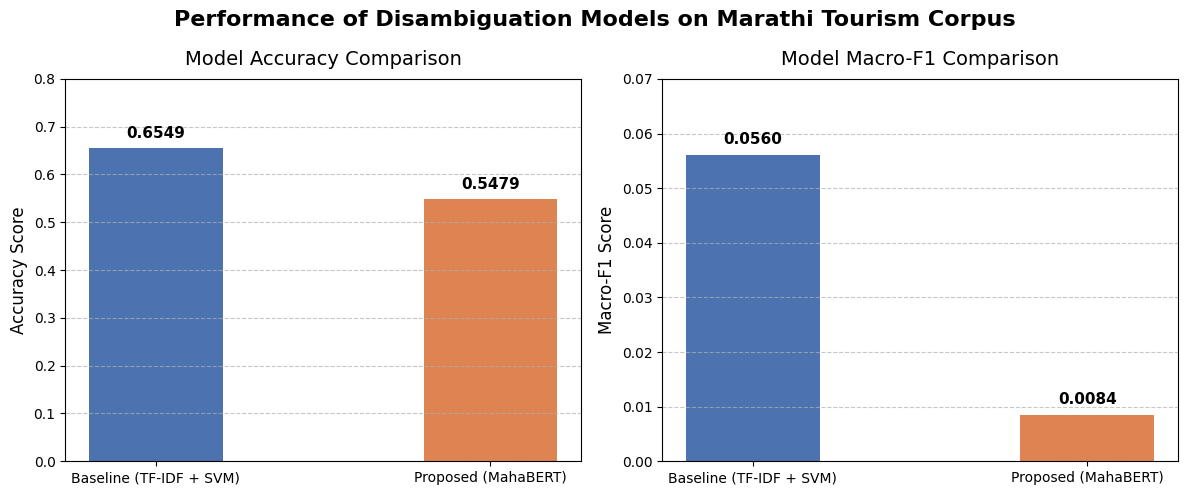

Chart successfully saved as 'results_chart.png'


In [ ]:
import matplotlib.pyplot as plt
import numpy as np


models = ['Baseline (TF-IDF + SVM)', 'Proposed (MahaBERT)']
accuracy = [0.6549, 0.5479]
macro_f1 = [0.0560, 0.0084]

# Setup for the side-by-side bar charts
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# --- Plot 1: Accuracy ---
bars1 = ax1.bar(models, accuracy, color=['#4C72B0', '#DD8452'], width=0.4)
ax1.set_ylabel('Accuracy Score', fontsize=12)
ax1.set_title('Model Accuracy Comparison', fontsize=14, pad=10)
ax1.set_ylim(0, 0.8) # Gives headroom for the labels
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Add data labels on top of bars
for bar in bars1:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 0.015, f"{yval:.4f}",
             ha='center', va='bottom', fontweight='bold', fontsize=11)

# --- Plot 2: Macro F1 ---
bars2 = ax2.bar(models, macro_f1, color=['#4C72B0', '#DD8452'], width=0.4)
ax2.set_ylabel('Macro-F1 Score', fontsize=12)
ax2.set_title('Model Macro-F1 Comparison', fontsize=14, pad=10)
ax2.set_ylim(0, 0.07) # Gives headroom for the labels
ax2.grid(axis='y', linestyle='--', alpha=0.7)

# Add data labels on top of bars
for bar in bars2:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval + 0.0015, f"{yval:.4f}",
             ha='center', va='bottom', fontweight='bold', fontsize=11)

# Add a main title for the whole figure
plt.suptitle('Performance of Disambiguation Models on Marathi Tourism Corpus',
             fontsize=16, fontweight='bold')

plt.tight_layout()

# Display and save high-resolution image for the paper
plt.savefig('results_chart.png', dpi=300, bbox_inches='tight')
plt.show()

print("Chart successfully saved as 'results_chart.png'")